In [ ]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


Program 1

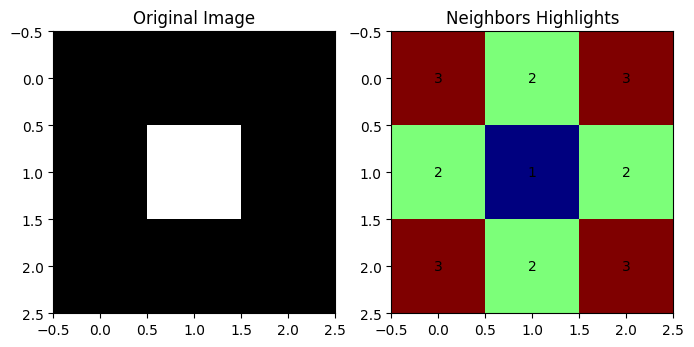

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_neighbors(p, shape):
    x,y = p
    nrows, ncols = shape
    N4 = [(x+1, y), (x-1, y), (x, y+1),(x, y-1)]
    N4 = [(i,j) for i, j in N4 if 0<= i <nrows and 0 <= j< ncols]
    ND = [(x+1, y+1), (x+1,y-1), (x-1,y+1), (x-1, y-1)]
    ND = [(i,j) for i, j in ND if 0<= i <nrows and 0 <= j< ncols]
    N8 =  N4 + ND
    return N4, ND, N8

binary_image = np.zeros((3,3), dtype=int)
binary_image[1,1] = 1

p = (1,1)
N4, ND, N8 = get_neighbors(p, binary_image.shape)
neighbor_image = binary_image.copy()
for n in N4:
    neighbor_image[n] = 2
for n in ND:
    neighbor_image[n] = 3
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(binary_image, cmap='gray', interpolation ='nearest')
ax[0].set_title('Original Image')
ax[1].imshow(neighbor_image, cmap='jet', interpolation ='nearest')
ax[1].set_title('Neighbors Highlights')
for i in range (neighbor_image.shape[0]):
    for j in range(neighbor_image.shape[1]):
        ax[1].text(j,i, neighbor_image[i,j], ha='center', va='center', color ='black')
plt.show()



Program 2

Are pixels (1, 0) and (0, 0) 4-adjacent? True
Are pixels (1, 0) and (0, 0) 8-adjacent? True


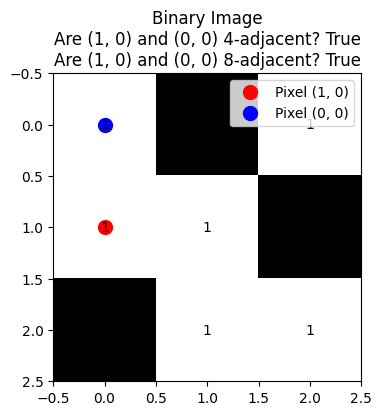

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to get N4, ND, N8 neighbors of a pixel
def get_neighbors(p, shape):
    x, y = p
    nrows, ncols = shape

    # N4 (4-neighbors: up, down, left, right)
    N4 = [(x+1, y), (x-1, y), (x, y+1), (x, y-1)]
    N4 = [(i, j) for i, j in N4 if 0 <= i < nrows and 0 <= j < ncols]  # Ensure within bounds

    # ND (Diagonal neighbors)
    ND = [(x+1, y+1), (x+1, y-1), (x-1, y+1), (x-1, y-1)]
    ND = [(i, j) for i, j in ND if 0 <= i < nrows and 0 <= j < ncols]

    # N8 (8-neighbors: N4 + ND)
    N8 = N4 + ND

    return N4, ND, N8

# Function to check adjacency
def check_adjacency(p, q, img, adj_type='4'):
    if adj_type == '4':
        neighbors, _, _ = get_neighbors(p, img.shape)
    elif adj_type == '8':
        _, _, neighbors = get_neighbors(p, img.shape)

    # Check if q is in p's neighbors and they have the same value in the binary image
    return q in neighbors and img[p] == img[q]

# Create a binary image
img = np.array([[1, 0, 1],
                [1, 1, 0],
                [0, 1, 1]])  # Binary image

# Define two pixels to check adjacency
p = (1, 0)
q = (0, 0)

# Check adjacency
adjacent_4 = check_adjacency(p, q, img, '4')  # 4-adjacency check
adjacent_8 = check_adjacency(p, q, img, '8')  # 8-adjacency check

# Print result
print(f"Are pixels {p} and {q} 4-adjacent? {adjacent_4}")
print(f"Are pixels {p} and {q} 8-adjacent? {adjacent_8}")

# Visualize the binary image
fig, ax = plt.subplots(figsize=(4, 4))

# Display the binary image
ax.imshow(img, cmap='gray', interpolation='nearest')
ax.set_title(f'Binary Image\nAre {p} and {q} 4-adjacent? {adjacent_4}\nAre {p} and {q} 8-adjacent? {adjacent_8}')

# Mark pixels p and q
ax.plot(p[1], p[0], 'ro', label=f'Pixel {p}', markersize=10)  # Red for pixel p
ax.plot(q[1], q[0], 'bo', label=f'Pixel {q}', markersize=10)  # Blue for pixel q

# Add pixel value text
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        ax.text(j, i, img[i, j], ha='center', va='center', color='black')

# Show the plot with pixel markers
plt.legend()
plt.show()


Program 3

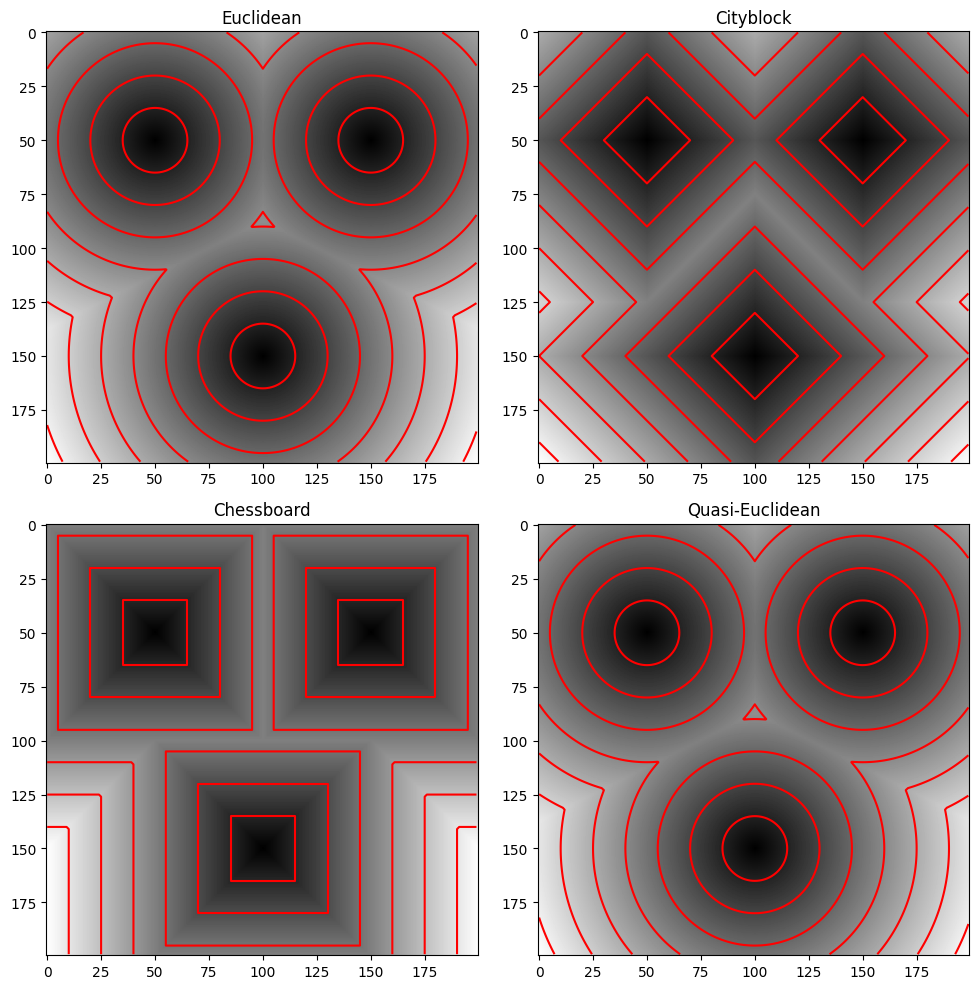

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, distance_transform_cdt

# Create binary image
bw = np.zeros((200, 200))
bw[50, 50] = 1
bw[50, 150] = 1
bw[150, 100] = 1

# Euclidean distance
D1 = distance_transform_edt(1 - bw)

# Cityblock (Manhattan) distance
D2 = distance_transform_cdt(1 - bw, metric='taxicab')

# Chessboard distance
D3 = distance_transform_cdt(1 - bw, metric='chessboard')

# Quasi-Euclidean distance
D4 = distance_transform_edt(1 - bw, return_distances=True)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Euclidean
axs[0, 0].imshow(D1, cmap='gray')
axs[0, 0].contour(D1, colors='r')
axs[0, 0].set_title('Euclidean')

# Cityblock
axs[0, 1].imshow(D2, cmap='gray')
axs[0, 1].contour(D2, colors='r')
axs[0, 1].set_title('Cityblock')

# Chessboard
axs[1, 0].imshow(D3, cmap='gray')
axs[1, 0].contour(D3, colors='r')
axs[1, 0].set_title('Chessboard')

# Quasi-Euclidean
axs[1, 1].imshow(D4, cmap='gray')
axs[1, 1].contour(D4, colors='r')
axs[1, 1].set_title('Quasi-Euclidean')

plt.tight_layout()
plt.show()
